# <u>GPU Training and Model Tuning</u>

In [ ]:
# Comment the following lines if you're not in colab:
from google.colab import drive
drive.mount('/content/drive')
# If you're in colab, cd to your own working directory here:
%cd ..//..//content//drive//MyDrive//Colab-Notebooks//HY-673-Tutorials//Tutorial-4

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[Errno 2] No such file or directory: '..//..//content//drive//MyDrive//Colab-Notebooks//HY-673-Tutorials//Tutorial-4'
/content/drive/MyDrive/Colab-Notebooks/HY-673-Tutorials/Tutorial-4


In [ ]:
!pip install torchinfo

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import torch as tc
import torch.nn as nn
from torch.utils.data import random_split, DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torchinfo import summary

In [ ]:
seed = 42
np.random.seed(seed)
tc.manual_seed(seed)

## <u>CUDA</u>

PyTorch uses **CUDA** to accelerate tensor operations on **Nvidia GPUs**. There is also **ROCm** support for AMD GPUs, but we will not cover it here.

To train a model on an Nvidia GPU you need to:

- Install the **CUDA drivers** supported by the current PyTorch version  
- Install **PyTorch with CUDA support**  
- Move tensors and models to the GPU

You can check the compatible CUDA versions here:  
https://pytorch.org/

### Moving tensors to the GPU

Tensors can be moved to the GPU like this:

```python
tensor = tensor.to("cuda")
# or:
tensor = tensor.cuda()
```

A cleaner approach is to **define the device when creating the tensor**:

```python
device = "cuda"
x = tc.tensor(5, device=device)
```

### Important: tensors must be on the same device

Operations between tensors require them to be located on the **same device**.

For example, the following will raise an error:

```python
tc.tensor([5, 5], device="cpu") + tc.tensor([10, 1], device="cuda")
```

because one tensor is on the **CPU** and the other is on the **GPU**.

### <u>Recommended Device Handling</u>

To safeguard against these issues, it is common to automatically select the
available device (**GPU if available, otherwise CPU**):

```python
device = tc.device("cuda" if tc.cuda.is_available() else "cpu")
print(device)
```

You can then consistently move tensors and models to this device:

```python
x = tc.tensor([1.0, 2.0, 3.0], device=device)
model = model.to(device)
```

We will not delve into how to handle multiple GPUs, as this requires additional concepts such as data/model parallelism and distributed training, which are beyond our scope.

In [ ]:
device = tc.device("cuda" if tc.cuda.is_available() else "cpu")
print(f"Using {device}")

Using cuda


## <u>Validation and Hyperparameters</u>

Once we have assembled our architecture, there are still many aspects that we can tune in order to improve performance. For example, we can change the **batch size**, **learning rate**, **number of training epochs**, or other application-specific hyperparameters.

Ideally, we want to select parameters that provide good **generalization capability**. For instance, we would like to find a suitable number of training epochs so that the model learns the data well **without overfitting or underfitting**.

However, we **cannot use the test dataset** for this process. It is tempting to do so (and many people unfortunately do it), but if you select hyperparameters based on test performance, you are essentially using the test data to **train** your model.

**REMEMBER:** You should use the **test dataset only once**, to evaluate your **final model**. Never use the test dataset before the model is ready to be deployed.

So how do we tune our model to achieve good generalization? A common solution is to split the available training data into two parts:

- **Training set** → used to update the model parameters  
- **Validation set** → used to tune hyperparameters

The validation set allows us to compare different hyperparameter choices while keeping the <u>**test dataset completely untouched**</u>.

In [ ]:
# hyperparameters
batch_size = 16
lr = 8e-4
n_epochs = 100
adam_betas = (0.9, 0.9)
train_val_split = [.8, .2]

**Note:** The MNIST dataset already comes with two predefined, non-overlapping splits:

- `train=True` → 60,000 training images  
- `train=False` → 10,000 test images  

The test set contains **different samples** and is **never used during training**.  It is reserved only for the **final evaluation** of the model.

In [ ]:
datapath = 'data'

# load dataset:
data_train = MNIST(
    root = datapath,
    train = True,
    transform = ToTensor(),
    download = True
)
data_test = MNIST(
    root = datapath,
    train = False,
    transform = ToTensor(),
    download = True
)

# Keep some data for validation:
data_train, data_val = random_split(
    dataset=data_train,
    lengths=train_val_split,
    generator=tc.Generator()
)

Before training the model, it is good practice to inspect samples from the dataset. Here, each MNIST image is a **28×28 grayscale tensor**, paired with a **label indicating the digit (0–9)** it represents:

digit.shape = torch.Size([1, 28, 28])


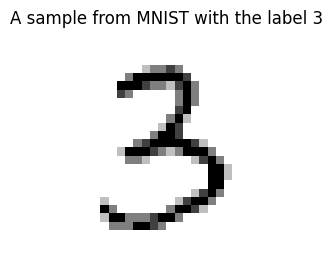

In [ ]:
digit, label = data_train[0]
digit = digit.to(device)
print(f"digit.shape = {digit.shape}")

plt.figure(figsize=(3,3))
plt.imshow(digit[0].cpu(), cmap='binary')
plt.axis('off')
plt.title(f"A sample from MNIST with the label {label}")
plt.show()
plt.close()

Next, we create **DataLoaders** for the training, validation, and test datasets.  
All three datasets contain <u>**non-overlapping samples**</u>: the training set was split into separate training and validation subsets, and the MNIST test set is a **different predefined split**.

The DataLoaders handle **batching**, **shuffling**, and efficient data loading during training and evaluation.

In [ ]:
train_loader = DataLoader(
    dataset=data_train,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=True,
    num_workers=2
)

val_loader = DataLoader(
    dataset=data_val,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=True,
    num_workers=2
)

test_loader = DataLoader(
    dataset=data_test,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=True,
    num_workers=2
)

print(f"Dataset sizes:\n Train = {len(data_train)}\n Val   = {len(data_val)}\n Test  = {len(data_test)}")

Dataset sizes:
 Train = 48000
 Val   = 12000
 Test  = 10000


This time, we will build a slightly larger **Multilayer Perceptron (MLP)** to classify MNIST digits.

Since MLPs operate on **1-dimensional feature vectors**, each image must first be **flattened** before being passed to the network: $X \in \mathbb{R}^{H \times W} \rightarrow \mathrm{flatten}(X) \in \mathbb{R}^{HW}$.

So here, the original 28×28 image will be reshaped into a vector of length $28^2$ = 784.

The network will then process this vector through several **fully connected layers** to produce the class logits:

In [ ]:
class SimpleMLP(nn.Module):
    """
    - input_shape: shape of a single input data point
    """
    def __init__(self, input_shape, n_classes):
        super(SimpleMLP, self).__init__()

        self.input_shape = np.asarray(input_shape)
        self.n_classes = n_classes

        self.seq_model = nn.Sequential(
            nn.Linear(in_features=self.input_shape.prod(), out_features=64),
            nn.PReLU(),
            nn.Linear(in_features=64, out_features=32),
            nn.PReLU(),
            nn.Linear(in_features=32, out_features=16),
            nn.ReLU(),
            nn.Linear(in_features=16, out_features=self.n_classes)
        )

    def forward(self, x):
        # make the input of shape (batch_size, height*weight):
        x = x.view(-1, self.input_shape.prod())
        logits = self.seq_model(x)
        return logits

Next, we create an instance of the model and perform a **forward pass** with a sample input. This allows us to verify that the network produces outputs with the expected shape and to inspect its architecture:

In [ ]:
model = SimpleMLP(input_shape=digit.shape, n_classes=10).to(device)
out = model(digit)
print(f"Input shape = {digit.shape}, Output shape = {out.shape}")
print(summary(model, input_size=digit.shape, device=device))

Input shape = torch.Size([1, 28, 28]), Output shape = torch.Size([1, 10])
Layer (type:depth-idx)                   Output Shape              Param #
SimpleMLP                                [1, 10]                   --
├─Sequential: 1-1                        [1, 10]                   --
│    └─Linear: 2-1                       [1, 64]                   50,240
│    └─PReLU: 2-2                        [1, 64]                   1
│    └─Linear: 2-3                       [1, 32]                   2,080
│    └─PReLU: 2-4                        [1, 32]                   1
│    └─Linear: 2-5                       [1, 16]                   528
│    └─ReLU: 2-6                         [1, 16]                   --
│    └─Linear: 2-7                       [1, 10]                   170
Total params: 53,020
Trainable params: 53,020
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.05
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.21
Estimated Total Size 

As in our previous tutorials, we define a small helper function to compute the **classification accuracy** of the model on a given dataset. The function performs a forward pass on all batches and compares the predicted class (the index of the largest logit) with the true labels:

In [ ]:
def model_accuracy(data_loader):
    n_total = 0
    n_correct = 0

    for x_batch_, y_batch_ in data_loader:
        x_batch_, y_batch_ = x_batch_.to(device), y_batch_.to(device)
        logits_batch_ = model(x_batch_)  # model's output scores
        n_total += len(y_batch_)
        n_correct += sum(logits_batch_.argmax(axis=-1) == y_batch_).item()
    return n_correct / n_total

print(f"Accuracies before training:\n Train = {model_accuracy(train_loader):.4f}\n Val   = {model_accuracy(val_loader):.4f}\n Test  = {model_accuracy(test_loader):.4f}")

Accuracies before training:
 Train = 0.1122
 Val   = 0.1130
 Test  = 0.1136


Define loss and optimizer:

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = tc.optim.Adam(model.parameters(), lr=lr, betas=adam_betas)

### <u>Overfitting and Early Stopping</u>

One of the most common problems in deep learning is **overfitting**. This occurs when a model performs well on the **training data**, but fails to generalize to **validation or test data**.

Typical signs of overfitting are **high training accuracy** together with **poor validation performance**.

There are several strategies to mitigate overfitting, for example:

- Reduce the **number of trainable parameters** ("weaken" the model)
- Use **regularization techniques** (e.g., Dropout, L1/L2 regularization, Batch Normalization)
- Collect more training data or use data augmentation techniques

A common approach if the last point is exhausted is **early stopping**. As the name suggests, early stopping interrupts the training process once the model **stops improving according to a chosen metric**, usually the **validation loss** or **validation accuracy**.

Typical early stopping parameters include:

- `patience`: the number of epochs to wait before stopping once the metric stops improving
- `min_delta`: the minimum change required to consider a new value an improvement (not used in this example)

In [ ]:
# Early stopping parameters:
patience = 5  # epochs
best_acc_val = 0.0
early_stop_counter = 0

Below is the main training loop for our MLP with **early stopping**.

At the end of each epoch we evaluate the model on the **training** and **validation** sets. If the validation accuracy improves, we **save the model weights** and reset the early stopping counter. Otherwise, we increase the counter, and if there is no improvement for `patience` number of consecutive epochs, the training stops:

In [ ]:
accuracies_train = []
accuracies_val = []

for epoch in range(n_epochs):

    for i, (x_batch, y_batch) in enumerate(train_loader):

        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        logits_batch = model(x_batch)
        loss_batch = loss_fn(input=logits_batch, target=y_batch)
        loss_batch.backward()
        optimizer.step()

    # evaluate the model at the end of each epoch:
    with tc.no_grad():

        acc_train = model_accuracy(train_loader)
        acc_val = model_accuracy(val_loader)
        print(f"Epoch {epoch+1:03d} | train_acc = {acc_train:.4f} | val_acc = {acc_val:.4f}")
        accuracies_train.append(acc_train)
        accuracies_val.append(acc_val)

        # save the weights iff the validation accuracy increased:
        if acc_val > best_acc_val:
            best_acc_val = acc_val
            early_stop_counter = 0
            tc.save(model.state_dict(), f"saved_models/MLP_GPU_epoch{epoch+1:03d}.pt")
        else:
            early_stop_counter += 1
            if early_stop_counter == patience:
                print(f"Validation accuracy has not improved in {patience} epochs: training stopped.")
                break

Epoch 001 | train_acc = 0.9256 | val_acc = 0.9188
Epoch 002 | train_acc = 0.9603 | val_acc = 0.9517
Epoch 003 | train_acc = 0.9648 | val_acc = 0.9528
Epoch 004 | train_acc = 0.9695 | val_acc = 0.9551
Epoch 005 | train_acc = 0.9798 | val_acc = 0.9652
Epoch 006 | train_acc = 0.9802 | val_acc = 0.9618
Epoch 007 | train_acc = 0.9809 | val_acc = 0.9627
Epoch 008 | train_acc = 0.9864 | val_acc = 0.9663
Epoch 009 | train_acc = 0.9849 | val_acc = 0.9661
Epoch 010 | train_acc = 0.9912 | val_acc = 0.9677
Epoch 011 | train_acc = 0.9893 | val_acc = 0.9652
Epoch 012 | train_acc = 0.9909 | val_acc = 0.9672
Epoch 013 | train_acc = 0.9879 | val_acc = 0.9626
Epoch 014 | train_acc = 0.9907 | val_acc = 0.9657
Epoch 015 | train_acc = 0.9907 | val_acc = 0.9675
Validation accuracy has not improved in 5 epochs: training stopped.


Let's visualize how the **training** and **validation accuracies** evolved during training:

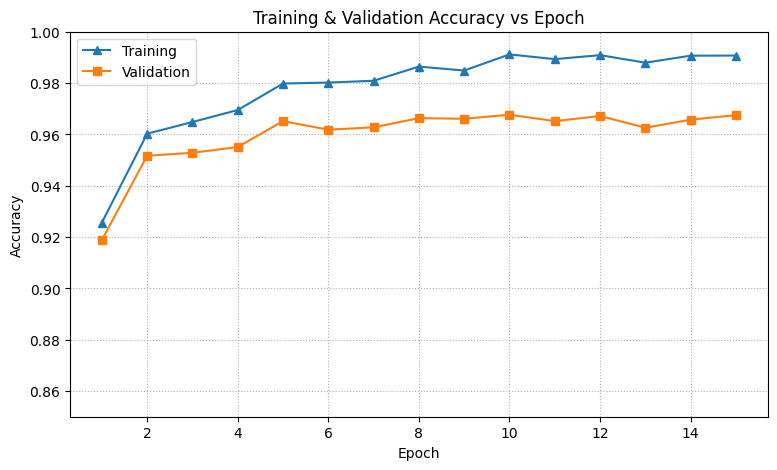

In [ ]:
ax_epoch = np.arange(start=1, stop=len(accuracies_train)+1, step=1)
plt.figure(figsize=(9,5))
plt.plot(ax_epoch, accuracies_train, '^-', label="Training")
plt.plot(ax_epoch, accuracies_val, 's-', label="Validation")
plt.grid(linestyle=':')
plt.ylim([0.85, 1.00])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy vs Epoch")
plt.legend()
plt.show()
plt.close()

If everything went smoothly, all accuracies should reach reasonably high values. A typical expected outcome is:

$1 > \text{train_acc} > \text{val_acc} > \text{test_acc} > 0$,

since the model is optimized on the **training set**, while the **validation** and **test sets** measure how well it generalizes to unseen data.

In [ ]:
print(f"Accuracies after training:\n Train = {model_accuracy(train_loader):.4f}\n Val   = {model_accuracy(val_loader):.4f}\n Test  = {model_accuracy(test_loader):.4f}")

Accuracies after training:
 Train = 0.9907
 Val   = 0.9675
 Test  = 0.9673


## <u>Homework (optional)</u>

- How sensitive is this model to **random initialization**?
- Try to find better hyperparameters while **reducing the total number of trainable parameters**, compromising accuracy as little as possible.
- Check whether the model correctly classifies digits generated from a **GMM**, like in our previous tutorial.